# Algorithms

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import alg4


rng = np.random.default_rng(seed=77)

## Algorithm 4

In [2]:
# trial
N_TRIAL = 100
ASPECT_RATIO = 0.9
D_TRIAL = int(ASPECT_RATIO * N_TRIAL)
Sigma_trial = np.eye(D_TRIAL)
M_THETA = 100
M_X = 50
M_Y = 50
EPSILON = 6.767

results = alg4.EvaluateFixedX(N_TRIAL, D_TRIAL, Sigma_trial, EPSILON, M_THETA, M_X, M_Y)

Evaluating theta values:   0%|          | 0/100 [00:00<?, ?it/s]

Bootstrap 1/9 complete: lambda_min
Bootstrap 2/9 complete: mse_min
Bootstrap 3/9 complete: lambda_fixed_pt
Bootstrap 4/9 complete: mse_fixed_pt
Bootstrap 5/9 complete: lambda_sample_fixed_pt
Bootstrap 6/9 complete: mse_sample_fixed_pt
Bootstrap 7/9 complete: lambda_signal_noise
Bootstrap 8/9 complete: mse_signal_noise
Bootstrap 9/9 complete: mse_default
Result 1:
Confidence interval: ConfidenceInterval(low=np.float64(2001.004004004004), high=np.float64(2001.004004004004))
Standard error: 2.2738504611687925e-13
Bootstrap distribution:
[2001.004 2001.004 2001.004 ... 2001.004 2001.004 2001.004]
Result 2:
Confidence interval: ConfidenceInterval(low=np.float64(47.4369129612938), high=np.float64(47.44814822339159))
Standard error: 0.0031587400090979053
Bootstrap distribution:
[47.441 47.441 47.441 ... 47.437 47.437 47.441]
Result 3:
Confidence interval: ConfidenceInterval(low=np.float64(1887.030816404275), high=np.float64(1894.1911021703318))
Standard error: 1.999564989344609
Bootstrap dist

In [ ]:
for index, result in enumerate(results, start=1):
    print(f"Result {index}:")
    print("Confidence interval:", result.confidence_interval)
    print("Standard error:", result.standard_error)
    print("Bootstrap distribution:")
    print(result.bootstrap_distribution)

ValueError: 'yerr' must not contain negative values

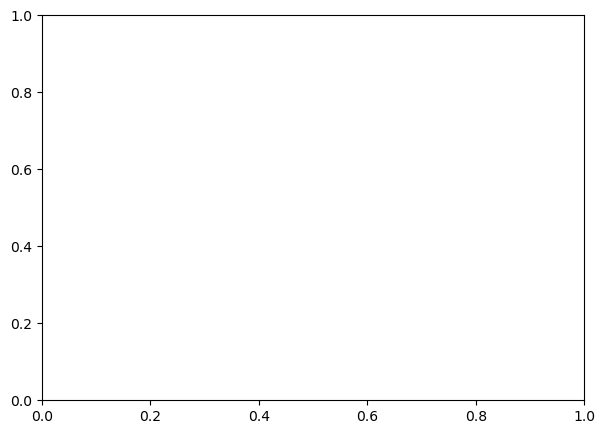

In [18]:
x = np.arange(1, len(results) + 1)

values = np.array([np.mean(r.bootstrap_distribution) for r in results])

ci_low  = np.array([r.confidence_interval.low  for r in results])
ci_high = np.array([r.confidence_interval.high for r in results])

yerr_lower = values - ci_low
yerr_upper = ci_high - values

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    x, values,
    yerr=[yerr_lower, yerr_upper],
    fmt='o',
    color='black',
    ecolor='gray',
    elinewidth=2,
    capsize=5,
    markersize=7,
)

ax.set_xticks(x)
ax.set_xlabel('Result')
ax.set_ylabel('Value')
ax.set_title('Bootstrap Estimates with Confidence Intervals')
plt.show()

## Algorithm 5